[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/muhammad-zainal-muttaqin/NulisBuku/blob/main/website/notebooks/ch03.ipynb)

Notebook Bab 3 ini punya dua bagian. Bagian **Demo** tinggal Anda jalankan lalu amati keluarannya; bagian **Mini Project** berisi soal dan data yang Anda kerjakan sendiri.

Skala fitur numerik memengaruhi model berbasis jarak (k-NN, SVM), tetapi tidak model berbasis pohon. Di sini kita mengukur efeknya pada data yang sama.

## Persiapan

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

RANDOM_STATE = 42
print('Setup selesai.')

Setup selesai.


## Section 1 - Demo: Efek Transformasi pada k-NN, SVM, dan Pohon

## Data dengan skala antar-fitur yang timpang

Tiap kolom sengaja dikalikan faktor berbeda agar rentang antar-fitur sangat jauh.

In [2]:
X, y = make_classification(n_samples=1500, n_features=8, n_informative=5,
                           n_redundant=0, random_state=RANDOM_STATE)
faktor = np.array([1, 100, 1, 1000, 1, 50, 1, 500])
Xs = X * faktor
print('Rentang tiap kolom (min .. max):')
for j in range(Xs.shape[1]):
    print(f'  fitur {j}: {Xs[:, j].min():8.1f} .. {Xs[:, j].max():8.1f}')

Rentang tiap kolom (min .. max):
  fitur 0:     -3.1 ..      3.1
  fitur 1:   -506.3 ..    471.5
  fitur 2:     -4.6 ..      5.9
  fitur 3:  -3757.4 ..   3398.1
  fitur 4:     -4.8 ..      4.8
  fitur 5:   -172.7 ..    177.2
  fitur 6:     -3.7 ..      5.2
  fitur 7:  -2287.5 ..   2575.0


## Bandingkan tanpa vs dengan *scaling*

*Scaling* diletakkan di dalam *pipeline* agar di-*fit* ulang pada tiap *fold cross-validation*.

In [3]:
models = {
    'k-NN': KNeighborsClassifier(),
    'SVM': SVC(),
    'Random Forest': RandomForestClassifier(random_state=RANDOM_STATE),
}
hasil = {}
for nama, m in models.items():
    tanpa = cross_val_score(m, Xs, y, cv=5).mean()
    dengan = cross_val_score(Pipeline([('sc', StandardScaler()), ('m', m)]), Xs, y, cv=5).mean()
    hasil[nama] = (tanpa, dengan)
    print(f'{nama:14s} tanpa scaling = {tanpa:.3f}   dengan scaling = {dengan:.3f}')

k-NN           tanpa scaling = 0.649   dengan scaling = 0.892


SVM            tanpa scaling = 0.674   dengan scaling = 0.915


Random Forest  tanpa scaling = 0.915   dengan scaling = 0.915


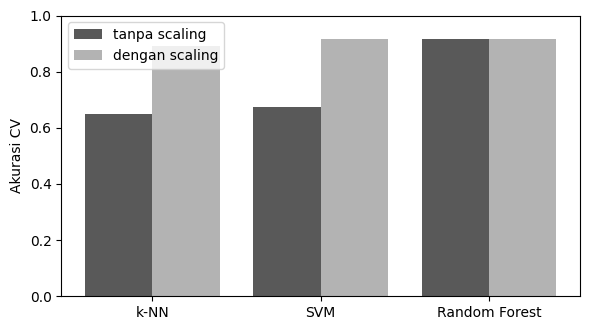

In [4]:
nama = list(hasil.keys())
tanpa = [hasil[k][0] for k in nama]
dengan = [hasil[k][1] for k in nama]
x = np.arange(len(nama))
fig, ax = plt.subplots(figsize=(6, 3.4))
ax.bar(x - 0.2, tanpa, 0.4, label='tanpa scaling', color='0.35')
ax.bar(x + 0.2, dengan, 0.4, label='dengan scaling', color='0.7')
ax.set_xticks(x)
ax.set_xticklabels(nama)
ax.set_ylabel('Akurasi CV')
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()

> 🔎 **Amati.** k-NN dan SVM melonjak setelah *scaling* karena keputusannya bergantung pada jarak antar-titik; tanpa penyeragaman skala, fitur berangka besar mendominasi. Random Forest hampir tidak berubah karena pemisahannya memakai ambang per fitur, bukan jarak.

## Section 2 - Mini Project

## Soal

Anda diberi data numerik dengan distribusi menceng dan skala antar-kolom yang timpang. Bangun *pipeline* yang menerapkan transformasi yang sesuai (misalnya *power transform* untuk kolom menceng dan *scaling* untuk penyeragaman rentang), lalu bandingkan satu model berbasis jarak dengan satu model berbasis pohon.

**Luaran:** kode *pipeline*, akurasi CV kedua model, dan 2-3 kalimat analisis kapan transformasi membantu.

**Kriteria penilaian:** (a) transformasi berada di dalam *pipeline*; (b) minimal dua keluarga model dibandingkan; (c) analisis menghubungkan hasil dengan sifat model.

In [5]:
# DATA AWAL (jangan diubah) - fitur menceng dan multi-skala.
Xr, yr = make_classification(n_samples=1200, n_features=6, n_informative=4,
                             n_redundant=0, random_state=7)
Xr[:, 1] = np.exp(Xr[:, 1])        # kolom menceng
Xr[:, 3] = Xr[:, 3] * 800          # kolom skala besar
Xr[:, 5] = np.abs(Xr[:, 5]) ** 3   # ekor panjang
print('Data:', Xr.shape, '| target seimbang:', np.bincount(yr))

Data: (1200, 6) | target seimbang: [598 602]


In [6]:
# Kerjakan di sini.
# Petunjuk: sklearn.preprocessing.PowerTransformer + StandardScaler di dalam Pipeline.
